In [1]:
!pip install -q torchmetrics torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.6 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import time
from pathlib import Path
import torch
from torch import nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torchmetrics.image.fid import FrechetInceptionDistance
from IPython.display import display

In [3]:
#SETUP
DEVICE = torch.device("cuda")
SEED, T, BATCH, LR, NULL = 42, 1000, 128, 1e-3, 10
ROOT = Path("genai-course/week2/homework")
(ROOT / "images").mkdir(parents=True, exist_ok=True)
transform = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))
])
train_data = datasets.FashionMNIST("data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST("data", train=False, download=True, transform=transform)
indices = torch.randperm(len(test_data), generator=torch.Generator().manual_seed(SEED))[:1000]
real_loader = DataLoader(Subset(test_data, indices.tolist()), batch_size=50)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.02MB/s]


In [4]:
#LAB-UNET
class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-torch.arange(half, device=t.device) *
                          (torch.log(torch.tensor(10000.0)) / (half - 1)))
        args = t[:, None].float() * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.time_mlp = nn.Linear(time_dim, ch)
        self.norm1 = nn.GroupNorm(8, ch)
        self.norm2 = nn.GroupNorm(8, ch)

    def forward(self, x, t_emb):
        h = torch.relu(self.conv1(self.norm1(x)))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        return x + self.conv2(torch.relu(self.norm2(h)))


class UNet(nn.Module):
    def __init__(self, time_dim=128, conditional=False):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmb(time_dim), nn.Linear(time_dim, time_dim), nn.ReLU())
        self.in_conv = nn.Conv2d(1, 32, 3, padding=1)

        # TLDR: Same lab encoder: 28 -> 14 -> 7 -> 4 pixels.
        self.enc1 = ResBlock(32, time_dim)
        self.down1 = nn.Conv2d(32, 64, 4, stride=2, padding=1)
        self.enc2 = ResBlock(64, time_dim)
        self.down2 = nn.Conv2d(64, 128, 4, stride=2, padding=1)
        self.enc3 = ResBlock(128, time_dim)
        self.down3 = nn.Conv2d(128, 128, 3, stride=2, padding=1)
        self.mid = ResBlock(128, time_dim)

        # TLDR: Same lab decoder and skip connections.
        self.up3 = nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1)
        self.merge3 = nn.Conv2d(256, 128, 1)
        self.dec3 = ResBlock(128, time_dim)
        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.merge2 = nn.Conv2d(128, 64, 1)
        self.dec2 = ResBlock(64, time_dim)
        self.up1 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.merge1 = nn.Conv2d(64, 32, 1)
        self.dec1 = ResBlock(32, time_dim)
        self.out_conv = nn.Conv2d(32, 1, 1)
        self.class_embed = nn.Embedding(11, time_dim) if conditional else None

    def forward(self, x, t, labels=None):
        emb = self.time_embed(t)
        if self.class_embed is not None:
            if labels is None:
                labels = torch.full((len(x),), NULL, device=x.device, dtype=torch.long)
            emb = emb + self.class_embed(labels)  # TLDR: Add class to time.
        s1 = self.enc1(self.in_conv(x), emb)
        s2 = self.enc2(self.down1(s1), emb)
        s3 = self.enc3(self.down2(s2), emb)
        h = self.mid(self.down3(s3), emb)
        h = self.dec3(self.merge3(torch.cat([self.up3(h), s3], 1)), emb)
        h = self.dec2(self.merge2(torch.cat([self.up2(h), s2], 1)), emb)
        h = self.dec1(self.merge1(torch.cat([self.up1(h), s1], 1)), emb)
        return self.out_conv(h)


In [5]:
#Schedules and Sampling
def schedule(name):
    if name == "A":
        return torch.linspace(1e-4, 0.02, T, device=DEVICE)
    s = {"B": 0.008, "C": 0.04}[name]
    t = torch.arange(T + 1, dtype=torch.float32) / T
    ab = torch.cos((t + s) / (1 + s) * torch.pi / 2) ** 2
    ab = ab / ab[0]
    return (1 - ab[1:] / ab[:-1]).clamp(0, 0.999).to(DEVICE)

@torch.no_grad()
def sample(model, betas, n=25, labels=None, w=3, seed=100):
    model.eval()
    a = 1 - betas
    ab = torch.cumprod(a, 0)
    prev = torch.cat([torch.ones(1, device=DEVICE), ab[:-1]])
    c0 = betas * prev.sqrt() / (1 - ab)
    ct = a.sqrt() * (1 - prev) / (1 - ab)
    std = (betas * (1 - prev) / (1 - ab)).sqrt()

    # Match starting noise AND every later noise draw across comparisons.
    rng = torch.Generator(device=DEVICE).manual_seed(seed)
    x = torch.randn((n, 1, 28, 28), generator=rng, device=DEVICE)
    if labels is not None:
        labels = labels.to(DEVICE)
        null = torch.full_like(labels, NULL)

    for i in reversed(range(len(betas))):
        t = torch.full((n,), i, device=DEVICE, dtype=torch.long)
        if labels is None:
            eps = model(x, t)
        else:
            # CFG: w=1 is ordinary class conditioning.
            u = model(x, t, null)
            eps = u + w * (model(x, t, labels) - u)

        # Keep the previous solution's clipped-x0 / posterior-variance sampler.
        x0 = ((x - (1 - ab[i]).sqrt() * eps) / ab[i].sqrt()).clamp(-1, 1)
        x = c0[i] * x0 + ct[i] * x
        if i > 0:
            x += std[i] * torch.randn(x.shape, generator=rng, device=DEVICE)
    return x.cpu()


In [6]:
#Image grid and FID
def grid(images, name, nrow=5, rows=None, cols=None):
    image = make_grid((images.clamp(-1, 1) + 1) / 2, nrow=nrow, padding=2)
    fig, ax = plt.subplots(figsize=(8, 1.2 * (len(images) // nrow) + 1))
    ax.imshow(image.permute(1, 2, 0))
    ax.set(title=name, xticks=[], yticks=[])
    if rows:
        ax.set_yticks([16 + 30 * i for i in range(len(rows))], rows)
    if cols:
        ax.set_xticks([16 + 30 * i for i in range(len(cols))], cols)
        ax.xaxis.tick_top()
    fig.savefig(ROOT / "images" / f"{name}.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)


def fid_input(x):
    # Grayscale [-1,1] -> RGB [0,1].
    return ((x.to(DEVICE).clamp(-1, 1) + 1) / 2).repeat(1, 3, 1, 1)


# Cache the same 1,000 real images; clear only fake statistics between runs.
fid = FrechetInceptionDistance(feature=2048, normalize=True,
                              reset_real_features=False, antialias=False).to(DEVICE)
fid.set_dtype(torch.float64)
fid.eval()
with torch.no_grad():
    for images, _ in real_loader:
        fid.update(fid_input(images), real=True)


@torch.no_grad()
def measure_fid(model, betas):
    fid.reset()
    for offset in range(0, 1000, 50):
        fake = sample(model, betas, n=50, seed=5000 + offset)
        fid.update(fid_input(fake), real=False)
    return fid.compute().item()


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 264MB/s]


In [7]:
#Training
def train(name, conditional=False, epochs=40):
    torch.manual_seed(SEED)
    model = UNet(conditional=conditional).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loader = DataLoader(train_data, batch_size=BATCH, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))
    betas = schedule(name)
    ab = torch.cumprod(1 - betas, 0)
    scores, seconds = {"Variant": name}, 0.0

    for epoch in range(1, epochs + 1):
        torch.manual_seed(SEED + epoch)
        model.train()
        total = 0.0
        torch.cuda.synchronize()
        start = time.perf_counter()

        for x, labels in loader:
            x, labels = x.to(DEVICE), labels.to(DEVICE)
            t = torch.randint(T, (len(x),), device=DEVICE)
            noise = torch.randn_like(x)
            alpha = ab[t, None, None, None]
            noisy = alpha.sqrt() * x + (1 - alpha).sqrt() * noise

            # Drop every label in a batch with 15% probability.
            if conditional and torch.rand(()).item() < 0.15:
                labels = torch.full_like(labels, NULL)
            predicted = model(noisy, t, labels if conditional else None)
            loss = F.mse_loss(predicted, noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total += loss.item() * len(x)

        torch.cuda.synchronize()
        seconds += time.perf_counter() - start  # Training only, not evaluation.
        print(f"{name} | epoch {epoch} | MSE {total / len(train_data):.4f}")

        if not conditional and epoch % 10 == 0:
            grid(sample(model, betas), f"{name}_epoch{epoch}")
            if epoch in (20, 40):
                scores[f"Epoch {epoch} FID"] = measure_fid(model, betas)

    scores["Training time (min)"] = seconds / 60
    torch.save(model.state_dict(), ROOT / f"{name}{'_cfg' if conditional else ''}.pt")
    return model, scores


PART 1

A | epoch 1 | MSE 0.0789
A | epoch 2 | MSE 0.0493
A | epoch 3 | MSE 0.0467
A | epoch 4 | MSE 0.0447
A | epoch 5 | MSE 0.0437
A | epoch 6 | MSE 0.0423
A | epoch 7 | MSE 0.0422
A | epoch 8 | MSE 0.0417
A | epoch 9 | MSE 0.0414
A | epoch 10 | MSE 0.0407


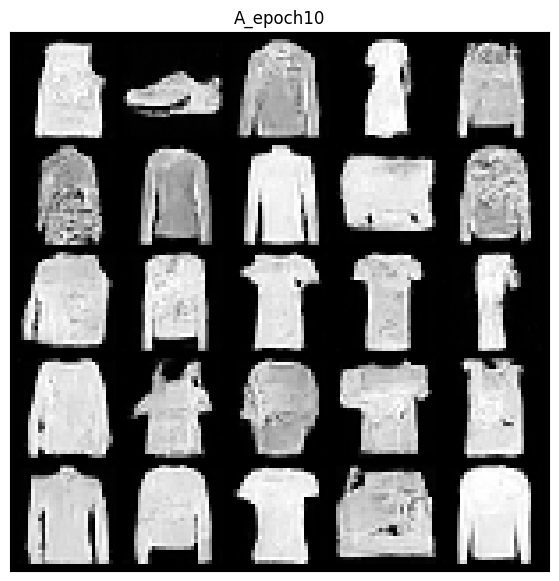

A | epoch 11 | MSE 0.0404
A | epoch 12 | MSE 0.0403
A | epoch 13 | MSE 0.0405
A | epoch 14 | MSE 0.0401
A | epoch 15 | MSE 0.0393
A | epoch 16 | MSE 0.0397
A | epoch 17 | MSE 0.0391
A | epoch 18 | MSE 0.0397
A | epoch 19 | MSE 0.0393
A | epoch 20 | MSE 0.0392


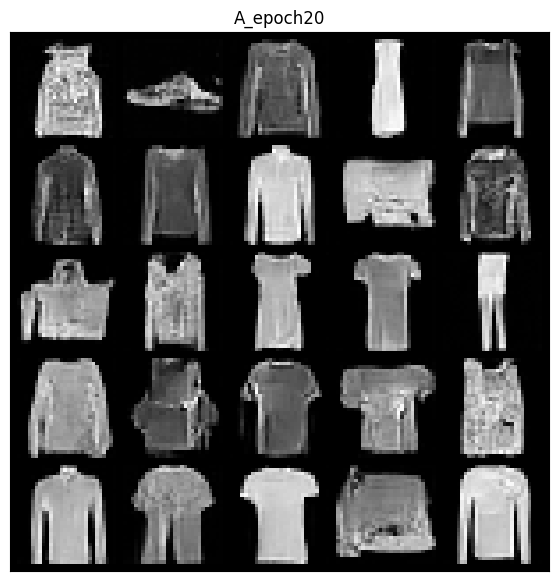

A | epoch 21 | MSE 0.0388
A | epoch 22 | MSE 0.0386
A | epoch 23 | MSE 0.0384
A | epoch 24 | MSE 0.0390
A | epoch 25 | MSE 0.0386
A | epoch 26 | MSE 0.0384
A | epoch 27 | MSE 0.0386
A | epoch 28 | MSE 0.0383
A | epoch 29 | MSE 0.0383
A | epoch 30 | MSE 0.0376


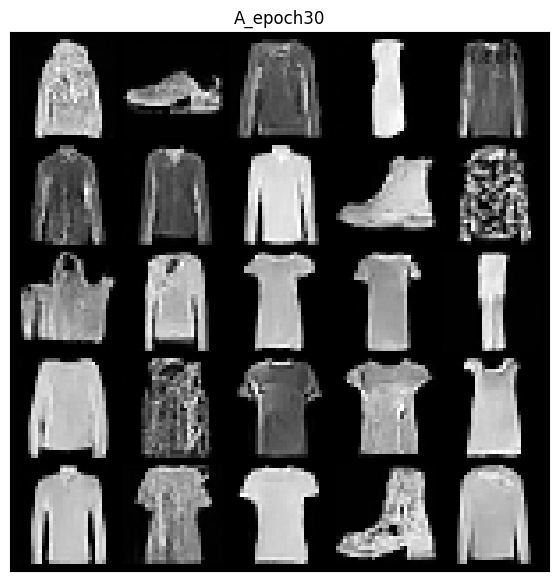

A | epoch 31 | MSE 0.0383
A | epoch 32 | MSE 0.0383
A | epoch 33 | MSE 0.0379
A | epoch 34 | MSE 0.0379
A | epoch 35 | MSE 0.0377
A | epoch 36 | MSE 0.0378
A | epoch 37 | MSE 0.0376
A | epoch 38 | MSE 0.0375
A | epoch 39 | MSE 0.0382
A | epoch 40 | MSE 0.0379


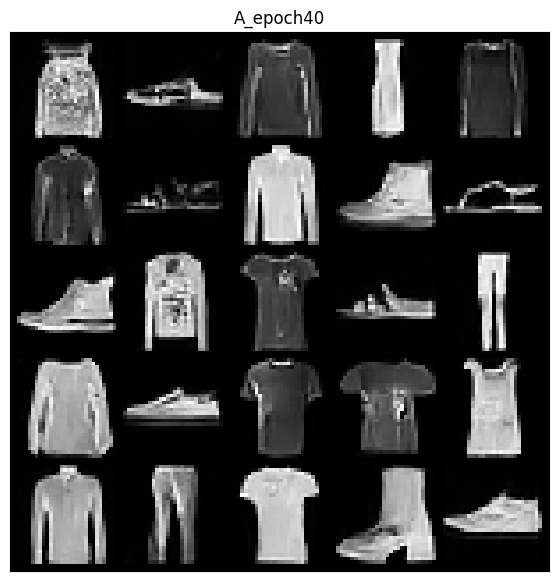

B | epoch 1 | MSE 0.1286
B | epoch 2 | MSE 0.0873
B | epoch 3 | MSE 0.0824
B | epoch 4 | MSE 0.0792
B | epoch 5 | MSE 0.0778
B | epoch 6 | MSE 0.0755
B | epoch 7 | MSE 0.0753
B | epoch 8 | MSE 0.0745
B | epoch 9 | MSE 0.0738
B | epoch 10 | MSE 0.0729


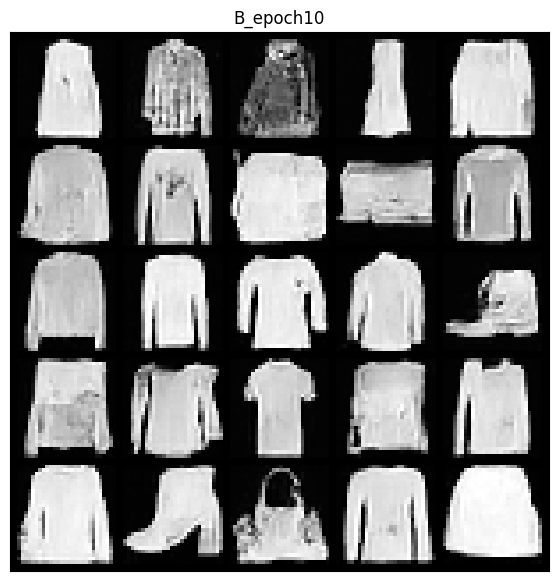

B | epoch 11 | MSE 0.0725
B | epoch 12 | MSE 0.0722
B | epoch 13 | MSE 0.0724
B | epoch 14 | MSE 0.0718
B | epoch 15 | MSE 0.0709
B | epoch 16 | MSE 0.0713
B | epoch 17 | MSE 0.0706
B | epoch 18 | MSE 0.0711
B | epoch 19 | MSE 0.0707
B | epoch 20 | MSE 0.0706


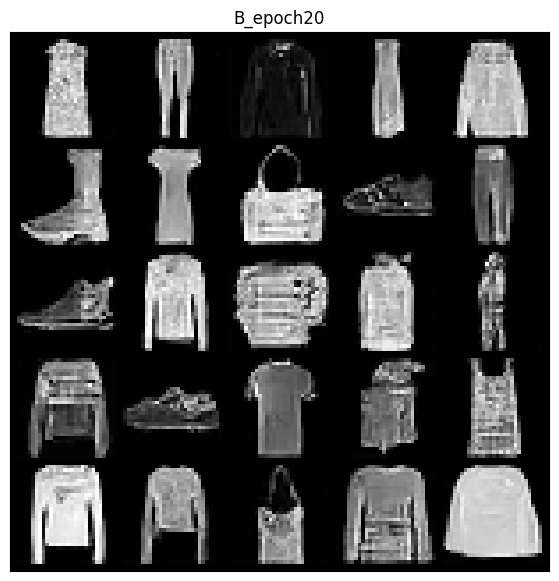

B | epoch 21 | MSE 0.0700
B | epoch 22 | MSE 0.0697
B | epoch 23 | MSE 0.0695
B | epoch 24 | MSE 0.0704
B | epoch 25 | MSE 0.0693
B | epoch 26 | MSE 0.0694
B | epoch 27 | MSE 0.0695
B | epoch 28 | MSE 0.0691
B | epoch 29 | MSE 0.0692
B | epoch 30 | MSE 0.0685


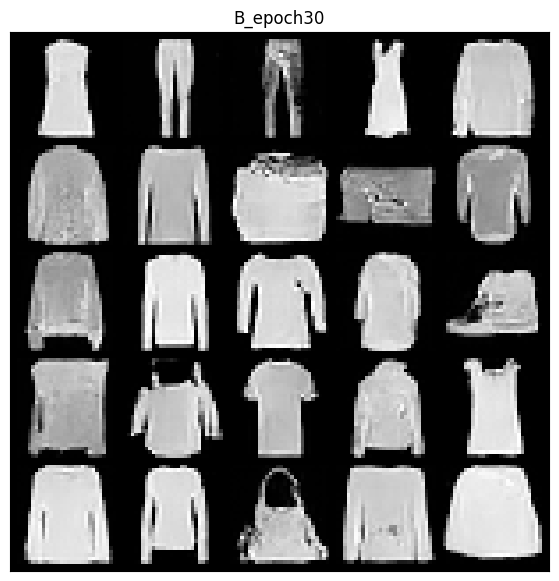

B | epoch 31 | MSE 0.0691
B | epoch 32 | MSE 0.0691
B | epoch 33 | MSE 0.0684
B | epoch 34 | MSE 0.0687
B | epoch 35 | MSE 0.0685
B | epoch 36 | MSE 0.0684
B | epoch 37 | MSE 0.0683
B | epoch 38 | MSE 0.0680
B | epoch 39 | MSE 0.0687
B | epoch 40 | MSE 0.0684


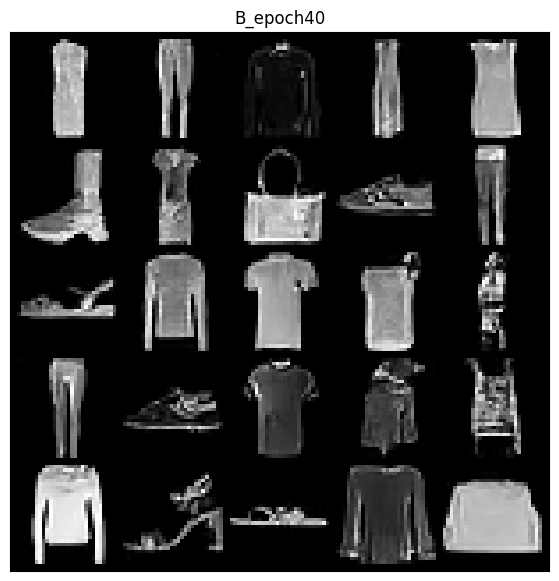

C | epoch 1 | MSE 0.1165
C | epoch 2 | MSE 0.0780
C | epoch 3 | MSE 0.0736
C | epoch 4 | MSE 0.0709
C | epoch 5 | MSE 0.0695
C | epoch 6 | MSE 0.0678
C | epoch 7 | MSE 0.0675
C | epoch 8 | MSE 0.0668
C | epoch 9 | MSE 0.0662
C | epoch 10 | MSE 0.0655


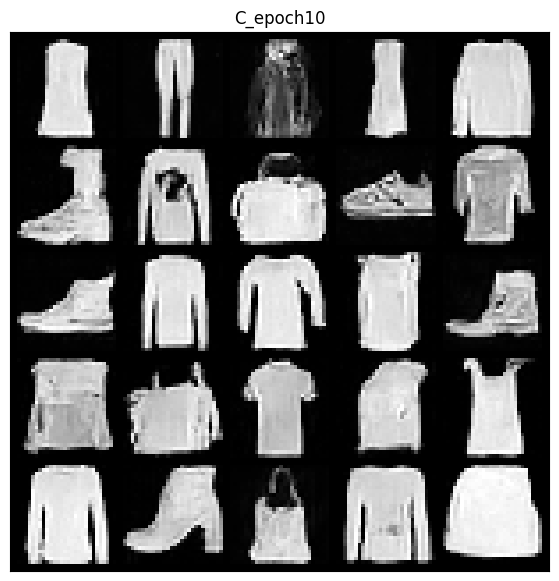

C | epoch 11 | MSE 0.0650
C | epoch 12 | MSE 0.0648
C | epoch 13 | MSE 0.0650
C | epoch 14 | MSE 0.0644
C | epoch 15 | MSE 0.0636
C | epoch 16 | MSE 0.0640
C | epoch 17 | MSE 0.0633
C | epoch 18 | MSE 0.0637
C | epoch 19 | MSE 0.0633
C | epoch 20 | MSE 0.0633


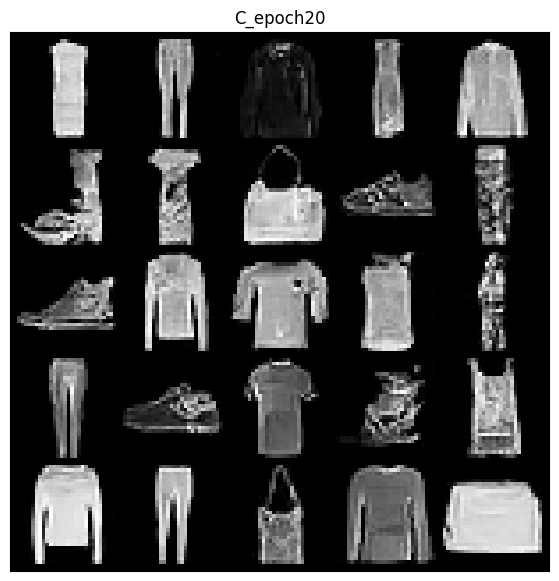

C | epoch 21 | MSE 0.0628
C | epoch 22 | MSE 0.0624
C | epoch 23 | MSE 0.0623
C | epoch 24 | MSE 0.0631
C | epoch 25 | MSE 0.0621
C | epoch 26 | MSE 0.0621
C | epoch 27 | MSE 0.0623
C | epoch 28 | MSE 0.0620
C | epoch 29 | MSE 0.0620
C | epoch 30 | MSE 0.0613


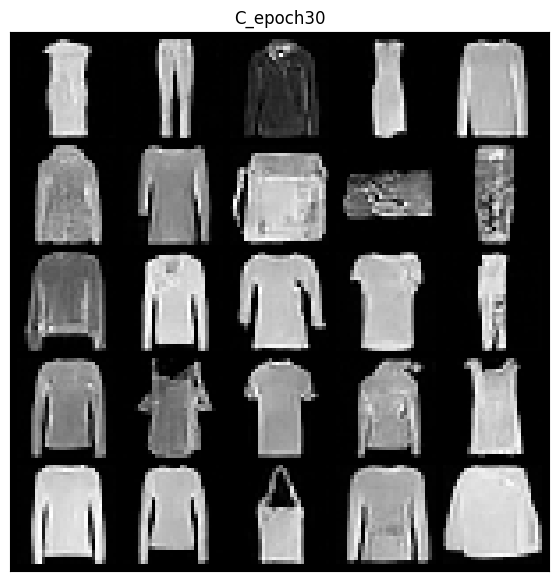

C | epoch 31 | MSE 0.0618
C | epoch 32 | MSE 0.0619
C | epoch 33 | MSE 0.0613
C | epoch 34 | MSE 0.0615
C | epoch 35 | MSE 0.0613
C | epoch 36 | MSE 0.0612
C | epoch 37 | MSE 0.0612
C | epoch 38 | MSE 0.0610
C | epoch 39 | MSE 0.0614
C | epoch 40 | MSE 0.0612


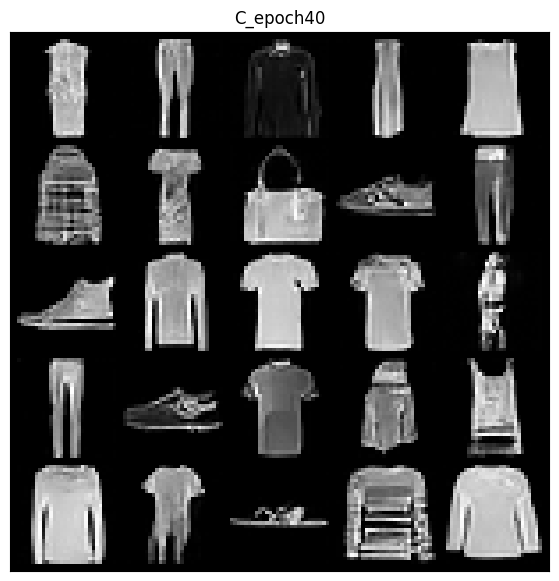

,Variant,Epoch 20 FID,Epoch 40 FID,Training time (min)
0,A,43.364,41.998,22.153
1,B,46.214,65.309,22.439
2,C,57.322,46.415,22.866


Lowest epoch-40 FID: A


In [8]:
# Three independent 40-epoch runs. Rerunning starts over.
# A: linear; B: cosine s=0.008; C: cosine s=0.04.
runs = {name: train(name) for name in ("A", "B", "C")}
table = pd.DataFrame([scores for model, scores in runs.values()])
table.to_csv(ROOT / "fid.csv", index=False)
display(table.round(3))
best = table.loc[table["Epoch 40 FID"].idxmin(), "Variant"]
print("Lowest epoch-40 FID:", best)


PART 1 Analysis:
Based on the experiments, I observed that the linear scheduled performed best, with FIDs of 43.36 at epoch 20 and ~42 at epoch 40, whle cosine only reached its lowest at 46. Training times were slightly above 20 minutes.

Intrestingly, both scheudles generated recognizable clothing relatiively early on (around epoch 10) but some shapes+textures took time to learn, such that even the lower training loss that was printed did not necessarily mean better images. After 20 epochs with the MNIST lab, there was no visual diferrence when it came to preference. However, since FMNIST is much more demanding when it comes to generation (clothing over simple stroke digits) I think the differences become more apparent. This is seen in the grids where, yes, the edges and the sihoulette of the garments are clear, but textures and shapes get easily distorted.

These results support choosing linear in my opinion for this specific challenge.

PART 2

A | epoch 1 | MSE 0.0950
A | epoch 2 | MSE 0.0518
A | epoch 3 | MSE 0.0486
A | epoch 4 | MSE 0.0456
A | epoch 5 | MSE 0.0443
A | epoch 6 | MSE 0.0426
A | epoch 7 | MSE 0.0425
A | epoch 8 | MSE 0.0415
A | epoch 9 | MSE 0.0414
A | epoch 10 | MSE 0.0408
A | epoch 11 | MSE 0.0404
A | epoch 12 | MSE 0.0403
A | epoch 13 | MSE 0.0405
A | epoch 14 | MSE 0.0404
A | epoch 15 | MSE 0.0393
A | epoch 16 | MSE 0.0395
A | epoch 17 | MSE 0.0390
A | epoch 18 | MSE 0.0396
A | epoch 19 | MSE 0.0391
A | epoch 20 | MSE 0.0391
A | epoch 21 | MSE 0.0385
A | epoch 22 | MSE 0.0383
A | epoch 23 | MSE 0.0383
A | epoch 24 | MSE 0.0389
A | epoch 25 | MSE 0.0383
A | epoch 26 | MSE 0.0381
A | epoch 27 | MSE 0.0384
A | epoch 28 | MSE 0.0380
A | epoch 29 | MSE 0.0380
A | epoch 30 | MSE 0.0374
A | epoch 31 | MSE 0.0380
A | epoch 32 | MSE 0.0379
A | epoch 33 | MSE 0.0376
A | epoch 34 | MSE 0.0375
A | epoch 35 | MSE 0.0373
A | epoch 36 | MSE 0.0375
A | epoch 37 | MSE 0.0373
A | epoch 38 | MSE 0.0371
A | epoch 39 | MSE 0.

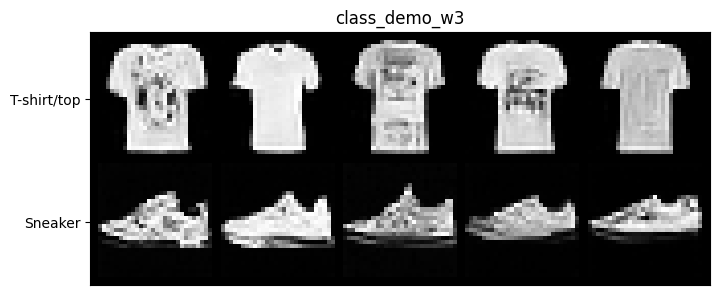

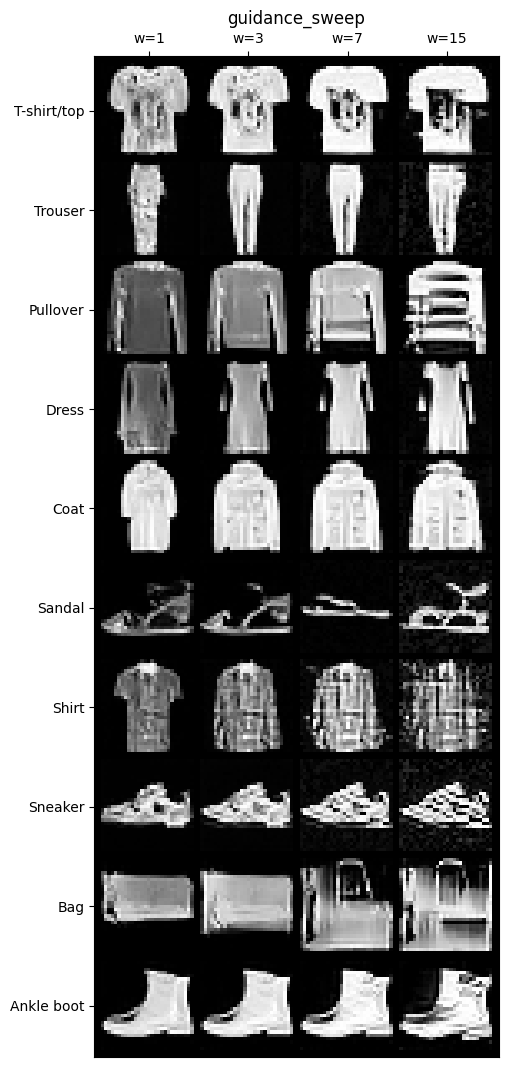

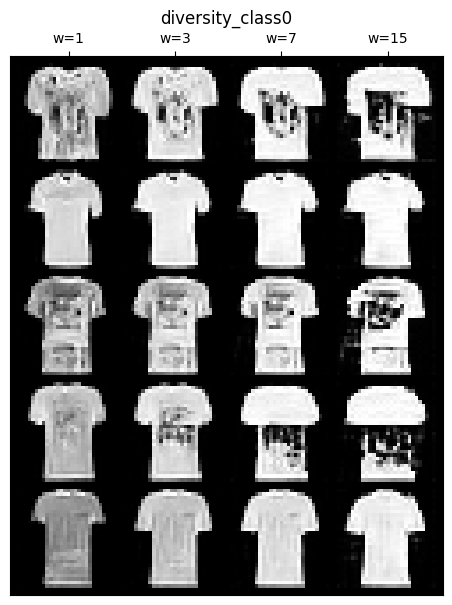

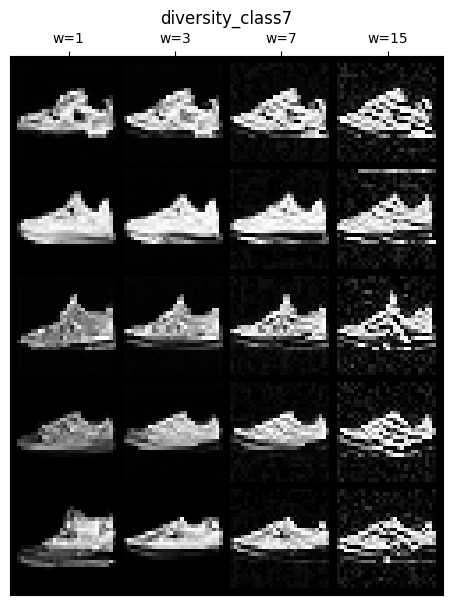

In [9]:
# Train a fresh conditional model; 40 epochs is our chosen budget.
model, _ = train(best, conditional=True)
labels = torch.arange(10).repeat_interleave(5)
scales = [1, 3, 7, 15]
sweeps = {w: sample(model, schedule(best), n=50, labels=labels, w=w, seed=2026)
          for w in scales}

# Five T-shirts and five sneakers at w=3.
grid(torch.cat([sweeps[3][:5], sweeps[3][35:40]]), "class_demo_w3",
     rows=["T-shirt/top", "Sneaker"])

# One row per class; columns are w=1, 3, 7, 15.
comparison = torch.stack([sweeps[w][c * 5] for c in range(10) for w in scales])
grid(comparison, "guidance_sweep", nrow=4, rows=train_data.classes,
     cols=[f"w={w}" for w in scales])

# Five examples per class show whether diversity changes.
for c in (0, 7):
    examples = torch.stack([sweeps[w][c * 5 + j] for j in range(5) for w in scales])
    grid(examples, f"diversity_class{c}", nrow=4,
         cols=[f"w={w}" for w in scales])


PART 2 Analysis

The linear schedule still provided recognizable shirts and sneakers at w=3, especially compared to w=1, with quality significantly degrading around w=7 (dark patches, specks, etc). Higher w values have stronger distortion without much better class composition. Diveristy maintains but there are still distrotions in each image at these higher wieghts. I found w=3 to bes the best for its balance between the classes and quality across the five examples, and that the larger weights amplify distortion throughout the images.